Yashwant_StudentPerformanceAnalysis.ipynb

# Student Performance Analysis and Prediction

## IBM SkillsBuild Data Analytics with AI Academic Internship Program

### Project Overview

This project analyzes student performance data to understand the factors associated with academic performance and develops machine learning models for student performance prediction.

### Objectives

- Inspect and understand the student performance dataset
- Clean and preprocess the data
- Perform exploratory data analysis
- Engineer relevant features
- Train machine learning models
- Evaluate model performance
- Perform cross-validation
- Analyze feature importance

# 1. Project Objective

The objective of this project is to analyze student performance data and identify
the factors associated with academic performance.

The project includes:

- Data loading and inspection
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Feature importance analysis
- Machine learning model development
- Model evaluation
- Cross-validation
- Hyperparameter tuning
- Final model selection
- Student performance prediction

The project aims to understand the relationship between student characteristics,
study habits, attendance, subject scores, and overall academic performance.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")  

Libraries imported successfully.


In [2]:
# Load the student performance dataset

import pandas as pd

df = pd.read_csv("Student_Performance.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (25000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [3]:
# Basic dataset information

print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non

In [4]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64


In [5]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 10000


In [6]:
# Statistical summary

df.describe(include="all")

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
count,25000.00000,25000.000000,25000,25000,25000,25000.000000,25000.000000,25000,25000,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000
unique,NaN,NaN,3,2,6,NaN,NaN,2,4,2,6,NaN,NaN,NaN,NaN,6
top,NaN,NaN,other,private,diploma,NaN,NaN,yes,15-30 min,yes,mixed,NaN,NaN,NaN,NaN,d
freq,NaN,NaN,8463,12725,4314,NaN,NaN,21227,6362,12500,4341,NaN,NaN,NaN,NaN,6311
mean,7493.04380,16.482760,NaN,NaN,NaN,4.253224,75.084084,NaN,NaN,NaN,NaN,63.785944,63.745320,63.681948,64.006172,NaN
std,4323.56215,1.703895,NaN,NaN,NaN,2.167541,14.373171,NaN,NaN,NaN,NaN,20.875262,20.970529,20.792693,18.932025,NaN
min,1.00000,14.000000,NaN,NaN,NaN,0.500000,50.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,14.500000,NaN
25%,3743.75000,15.000000,NaN,NaN,NaN,2.400000,62.800000,NaN,NaN,NaN,NaN,48.300000,48.200000,48.300000,49.000000,NaN
50%,7461.50000,16.000000,NaN,NaN,NaN,4.300000,75.100000,NaN,NaN,NaN,NaN,64.100000,64.100000,64.200000,64.200000,NaN
75%,11252.00000,18.000000,NaN,NaN,NaN,6.100000,87.500000,NaN,NaN,NaN,NaN,80.000000,80.000000,80.000000,79.000000,NaN


In [7]:
df = pd.read_csv("Student_Performance.csv")
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (25000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [8]:
print(df.columns.tolist())
df.info()

['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method    

In [9]:
print(df.isnull().sum())

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 10000


In [11]:
# Check dataset dimensions

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 25000
Columns: 16


In [12]:
# Display the first 5 rows

df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [13]:
# Check unique values in each column

print(df.nunique())

student_id               15000
age                          6
gender                       3
school_type                  2
parent_education             6
study_hours                 76
attendance_percentage      501
internet_access              2
travel_time                  4
extra_activities             2
study_method                 6
math_score                 906
science_score              907
english_score              904
overall_score              808
final_grade                  6
dtype: int64


In [14]:
# Compare the beginning and end of the dataset

print("First row:")
display(df.iloc[0])

print("\nLast row:")
display(df.iloc[-1])

First row:


student_id                           1
age                                 14
gender                            male
school_type                     public
parent_education         post graduate
study_hours                        3.1
attendance_percentage             84.3
internet_access                    yes
travel_time                    <15 min
extra_activities                   yes
study_method                     notes
math_score                        42.7
science_score                     55.4
english_score                     57.0
overall_score                     53.1
final_grade                          e
Name: 0, dtype: object


Last row:


student_id                   11621
age                             18
gender                       other
school_type                 public
parent_education         no formal
study_hours                    0.7
attendance_percentage         60.3
internet_access                yes
travel_time              30-60 min
extra_activities                no
study_method                 mixed
math_score                    36.5
science_score                 45.1
english_score                 16.5
overall_score                 31.4
final_grade                      f
Name: 24999, dtype: object

In [15]:
# Investigate duplicate rows

print("Total rows:", len(df))
print("Duplicated rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 25000
Duplicated rows: 10000
Unique rows: 15000


In [16]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
c:\Users\Owner\OneDrive\Desktop\Student analysis

Files in current folder:
['.git', '.gitignore', 'clean_data.py', 'eda_analysis.py', 'EDA_Charts', 'feature_engineering.py', 'feature_importance.py', 'final_gradient_boosting_model.joblib', 'final_model_results.txt', 'hyperparameter_tuning.py', 'inspect_data.py', 'investigate_issues.py', 'kfold_cv.py', 'ML_Results', 'ml_training.py', 'README.md', 'Student_Performance.csv', 'Student_Performance_Cleaned.csv', 'Student_Performance_ML_Ready.csv', 'validate_ml_ready.py', 'Yashwant_StudentPerformanceAnalysis.ipynb']


In [17]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 25000
Number of columns: 16


In [18]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [19]:
print(df.columns.tolist())

['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']


In [20]:
print(df.nunique())

student_id               15000
age                          6
gender                       3
school_type                  2
parent_education             6
study_hours                 76
attendance_percentage      501
internet_access              2
travel_time                  4
extra_activities             2
study_method                 6
math_score                 906
science_score              907
english_score              904
overall_score              808
final_grade                  6
dtype: int64


In [22]:
print(df.isnull().sum())

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64


In [23]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 25000
Duplicate rows: 10000
Unique rows: 15000


In [24]:
# Inspect duplicate records
duplicates = df[df.duplicated(keep=False)]

print("Total duplicate-related rows:", len(duplicates))
print("Number of duplicate groups:",
      duplicates.drop_duplicates().shape[0])

duplicates.head(10)

Total duplicate-related rows: 17265
Number of duplicate groups: 7265


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d
6,7,14,female,private,post graduate,1.8,81.6,yes,30-60 min,no,textbook,41.9,29.4,39.2,39.1,f
7,8,18,female,private,post graduate,5.6,59.4,yes,>60 min,yes,group study,56.7,60.1,53.4,69.6,d
9,10,14,female,public,diploma,6.8,62.4,yes,>60 min,no,mixed,71.9,70.4,81.3,69.6,d
11,12,19,other,public,post graduate,4.0,96.2,yes,<15 min,yes,notes,62.0,54.7,58.0,65.0,d
13,14,18,other,public,diploma,1.3,95.9,yes,30-60 min,yes,textbook,33.6,26.8,50.0,42.5,e
16,17,17,other,private,phd,2.3,67.3,yes,<15 min,yes,mixed,63.1,46.3,57.1,53.5,e


In [25]:
# Count how many times each exact row appears
duplicate_counts = df.value_counts()

print("Most frequently repeated rows:")
print(duplicate_counts.head(10))

Most frequently repeated rows:
student_id  age  gender  school_type  parent_education  study_hours  attendance_percentage  internet_access  travel_time  extra_activities  study_method  math_score  science_score  english_score  overall_score  final_grade
4781        19   male    public       diploma           5.8          55.3                   yes              >60 min      yes               textbook      65.6        79.8           82.0           68.4           d              7
3073        15   female  private      high school       5.2          67.6                   yes              <15 min      no                mixed         74.1        74.0           88.3           74.5           c              6
3720        15   male    private      no formal         3.1          72.5                   yes              15-30 min    yes               coaching      52.0        52.1           51.4           58.2           d              6
4525        18   male    public       phd               6.3   

In [26]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64


## 2. Data Cleaning

The dataset was checked for duplicate records and missing values.
No missing values were found. Exact duplicate records were identified
and removed to prepare the dataset for further analysis.

In [27]:
# Remove exact duplicate records
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 25000
Rows after removing duplicates: 15000
Rows removed: 10000


In [28]:
# Verify duplicate removal
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Duplicate rows after cleaning: 0


In [29]:
# Verify missing values after cleaning
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


# 3. Exploratory Data Analysis (EDA)

The cleaned dataset is explored to understand the distribution of student performance, relationships between features, and important factors associated with academic outcomes.

## 3.1 Descriptive Statistics

In [30]:
# Descriptive statistics
df_clean.describe()


,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,16.476400,4.25936,74.991760,63.774553,63.751227,63.709227,64.015500
std,4330.271354,1.704475,2.17244,14.401139,20.919958,21.027675,20.860201,18.977811
min,1.000000,14.000000,0.50000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3750.750000,15.000000,2.40000,62.600000,48.200000,48.100000,48.300000,49.000000
50%,7500.500000,16.000000,4.30000,75.000000,64.100000,64.000000,64.200000,64.300000
75%,11250.250000,18.000000,6.10000,87.400000,80.100000,80.100000,80.000000,79.100000
max,15000.000000,19.000000,8.00000,100.000000,100.000000,100.000000,100.000000,100.000000


## 3.2 Distribution of Numerical Variables

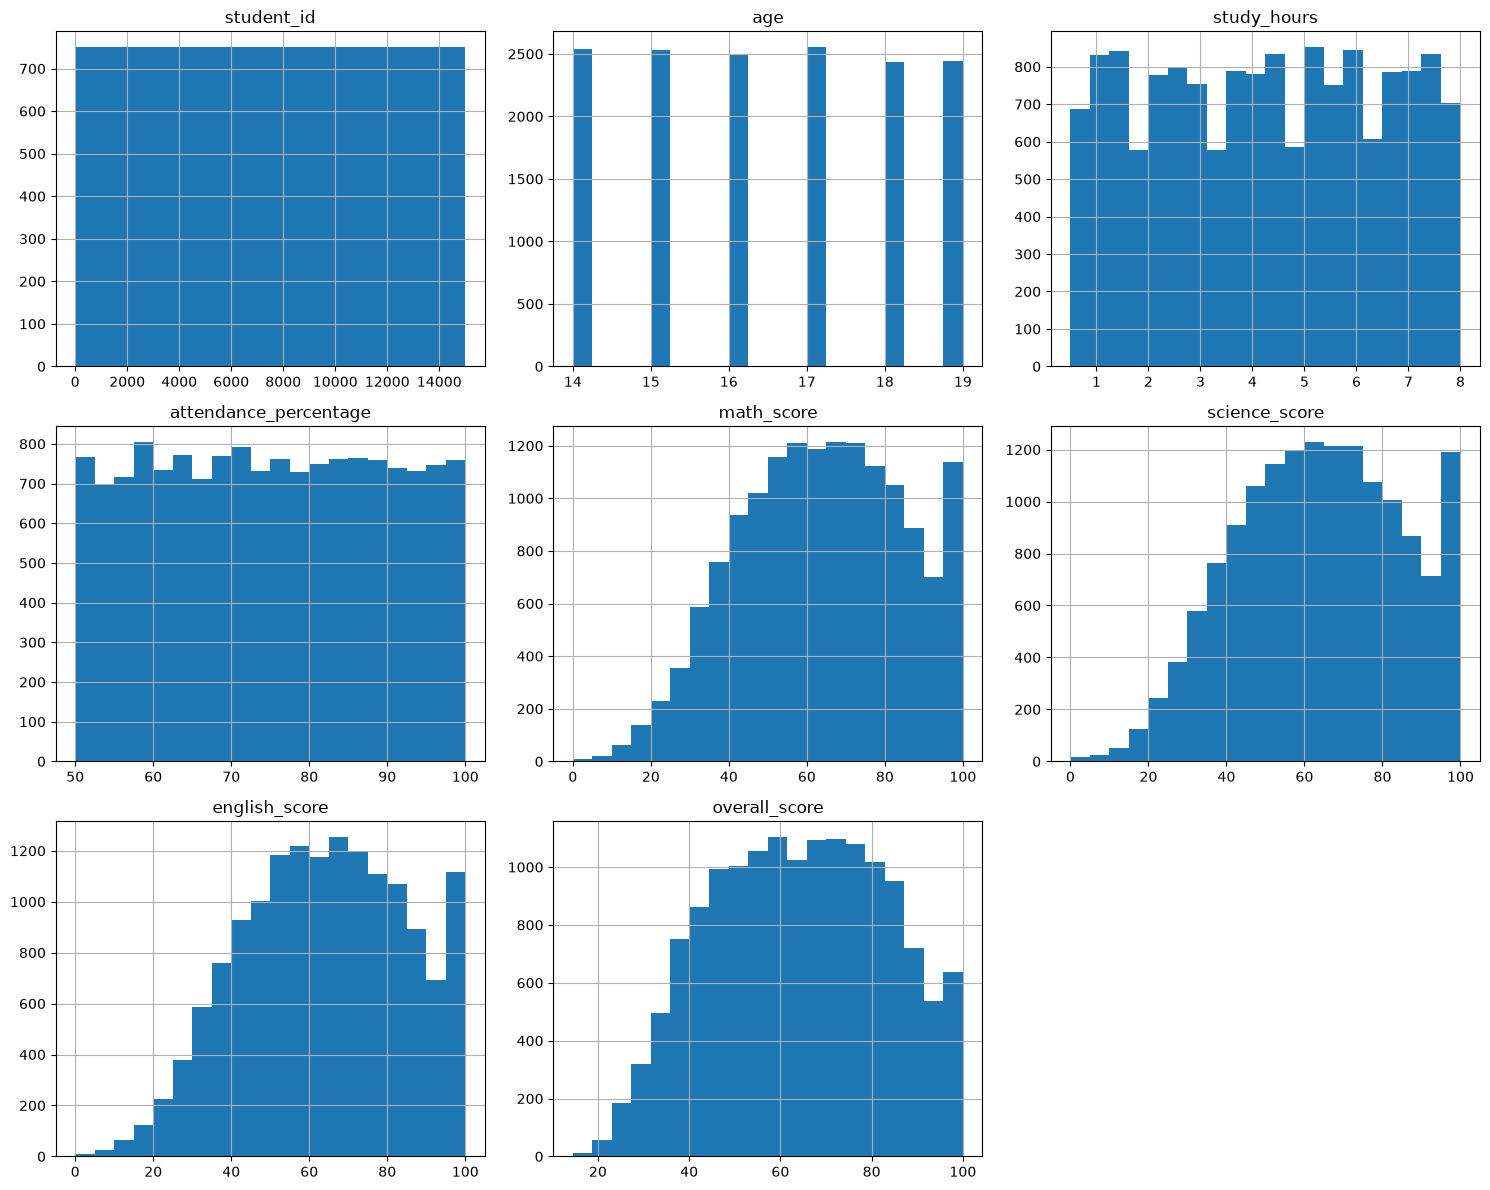

In [31]:
# Plot distributions of numerical variables
df_clean.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

## 3.3 Correlation Analysis

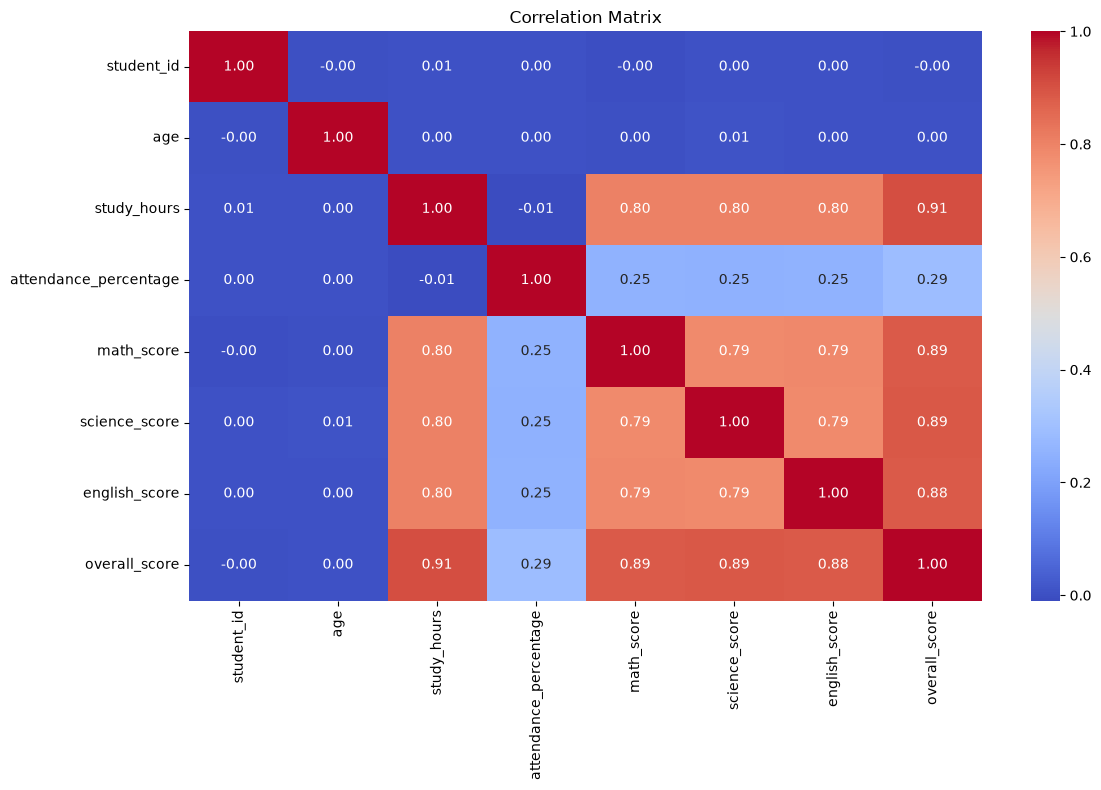

In [32]:
# Correlation matrix
correlation_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 3.4 Target Variable Analysis

In [33]:
print("Overall Score Statistics:")
print(df_clean["overall_score"].describe())

print("\nFinal Grade Distribution:")
print(df_clean["final_grade"].value_counts().sort_index())

Overall Score Statistics:
count    15000.000000
mean        64.015500
std         18.977811
min         14.500000
25%         49.000000
50%         64.300000
75%         79.100000
max        100.000000
Name: overall_score, dtype: float64

Final Grade Distribution:
final_grade
a     721
b    1638
c    3697
d    3770
e    3378
f    1796
Name: count, dtype: int64


## 3.5 Study Hours vs Academic Performance

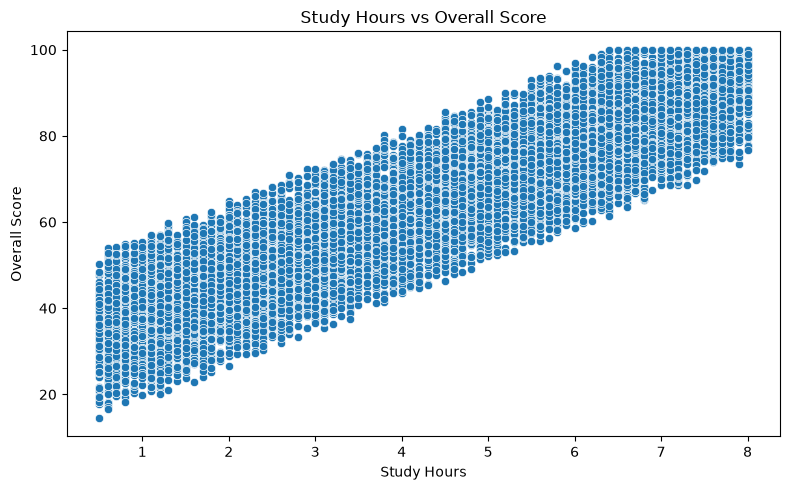

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="study_hours",
    y="overall_score"
)

plt.title("Study Hours vs Overall Score")
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.tight_layout()
plt.show()

## 3.6 Attendance vs Academic Performance

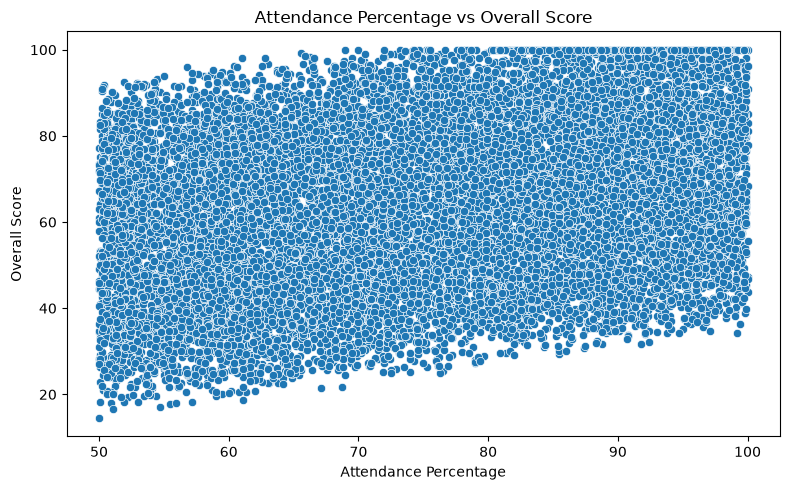

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="attendance_percentage",
    y="overall_score"
)

plt.title("Attendance Percentage vs Overall Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Overall Score")
plt.tight_layout()
plt.show()

## 3.7 Subject Score Analysis

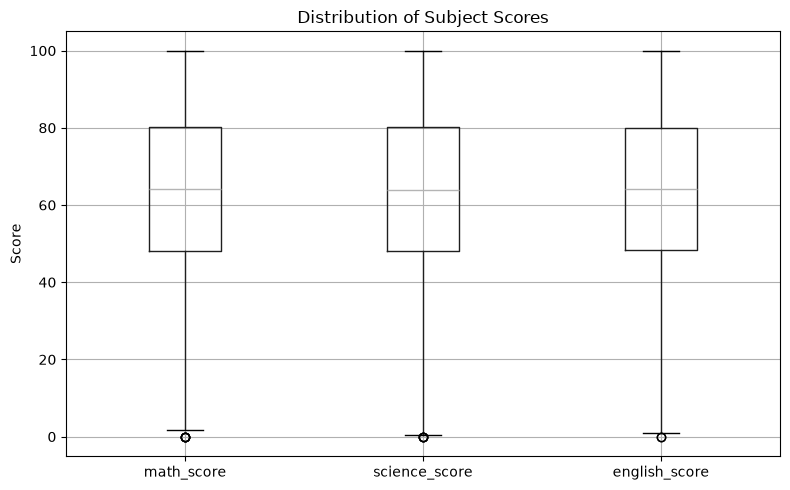

In [36]:
subject_columns = [
    "math_score",
    "science_score",
    "english_score"
]

df_clean[subject_columns].boxplot(figsize=(8, 5))

plt.title("Distribution of Subject Scores")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

### Interpretation

The boxplot shows the distribution of student scores across mathematics, science, and English.

The three subjects have broadly similar score distributions. The median scores are relatively high, while a small number of observations appear near zero, indicating the presence of low-score observations.

The distributions also show some variability among students, which suggests that academic performance differs across individuals.

These subject scores will be considered as important features during the feature engineering and machine learning stages.

# 4. Feature Engineering

Feature engineering prepares the cleaned dataset for machine learning by selecting relevant input features and defining the target variable. The aim is to create a consistent dataset that can be used to train and evaluate predictive models.

In [37]:
# Display the columns available for feature engineering
print("Available columns:")
print(df_clean.columns.tolist())

Available columns:
['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']


## 4.1 Data Types and Feature Structure

In [38]:
# Check data types
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  str    
 3   school_type            15000 non-null  str    
 4   parent_education       15000 non-null  str    
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  str    
 8   travel_time            15000 non-null  str    
 9   extra_activities       15000 non-null  str    
 10  study_method           15000 non-null  str    
 11  math_score             15000 non-null  float64
 12  science_score          15000 non-null  float64
 13  english_score          15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_grade  

# 4. Feature Engineering

The cleaned student performance dataset is transformed into a machine-learning-ready format using the project's feature engineering pipeline.

The feature engineering process includes:

- Numeric features are retained as numeric values.
- Binary categorical features are encoded as 0/1.
- Ordinal categorical features are encoded according to their natural order.
- Nominal categorical features are one-hot encoded.
- `final_grade` is encoded as `final_grade_encoded` for machine-learning classification.
- The original `final_grade` column is retained for interpretation and reporting.

In [39]:
# Load the ML-ready dataset

ml_df = pd.read_csv("Student_Performance_ML_Ready.csv")

print("ML-ready dataset shape:", ml_df.shape)
print("\nColumns:")
print(ml_df.columns.tolist())

ML-ready dataset shape: (15000, 21)

Columns:
['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score', 'internet_access', 'extra_activities', 'travel_time', 'parent_education', 'gender_female', 'gender_male', 'school_type_private', 'study_method_coaching', 'study_method_group_study', 'study_method_mixed', 'study_method_notes', 'study_method_online_videos', 'final_grade_encoded', 'final_grade']


In [40]:
# Display the first five rows of the ML-ready dataset

ml_df.head()

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,internet_access,extra_activities,travel_time,...,gender_female,gender_male,school_type_private,study_method_coaching,study_method_group_study,study_method_mixed,study_method_notes,study_method_online_videos,final_grade_encoded,final_grade
0,14,3.1,84.3,42.7,55.4,57.0,53.1,1,1,1,...,0,1,0,0,0,0,1,0,1,e
1,18,3.7,87.8,57.6,68.8,64.8,61.3,1,0,4,...,1,0,0,0,0,0,0,0,2,d
2,17,7.9,65.5,84.8,95.0,79.2,89.6,0,0,1,...,1,0,1,0,0,0,1,0,4,b
3,16,1.1,58.1,44.4,27.5,54.7,41.6,0,0,2,...,0,0,0,0,0,0,1,0,1,e
4,16,1.3,61.0,8.9,32.7,30.0,25.4,1,1,3,...,1,0,0,0,1,0,0,0,0,f


In [41]:
# Check data types and missing values

print("Data types:")
print(ml_df.dtypes)

print("\nTotal missing values:")
print(ml_df.isnull().sum().sum())

Data types:
age                             int64
study_hours                   float64
attendance_percentage         float64
math_score                    float64
science_score                 float64
english_score                 float64
overall_score                 float64
internet_access                 int64
extra_activities                int64
travel_time                     int64
parent_education                int64
gender_female                   int64
gender_male                     int64
school_type_private             int64
study_method_coaching           int64
study_method_group_study        int64
study_method_mixed              int64
study_method_notes              int64
study_method_online_videos      int64
final_grade_encoded             int64
final_grade                       str
dtype: object

Total missing values:
0


In [42]:
# Check the target variable distribution

print("Final grade encoded distribution:")
print(ml_df["final_grade_encoded"].value_counts().sort_index())

Final grade encoded distribution:
final_grade_encoded
0    1796
1    3378
2    3770
3    3697
4    1638
5     721
Name: count, dtype: int64


# 5. Machine Learning Preparation

The ML-ready dataset is now prepared for model training.

- `final_grade_encoded` is used as the target variable.
- `final_grade` is excluded from the predictors because it is the original form of the target and would cause target leakage.
- The data is divided into training and testing sets.
- Stratified splitting is used so that the class distribution is approximately preserved in both sets.

In [43]:
# Separate features (X) and target (y)

X = ml_df.drop(columns=["final_grade_encoded", "final_grade"])
y = ml_df["final_grade_encoded"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(sorted(y.unique()))

Feature matrix shape: (15000, 19)
Target shape: (15000,)

Features:
['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score', 'internet_access', 'extra_activities', 'travel_time', 'parent_education', 'gender_female', 'gender_male', 'school_type_private', 'study_method_coaching', 'study_method_group_study', 'study_method_mixed', 'study_method_notes', 'study_method_online_videos']

Target classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (12000, 19)
Testing features: (3000, 19)
Training target: (12000,)
Testing target: (3000,)


In [45]:
# Compare class distributions before and after the split

print("Original class distribution:")
print(y.value_counts(normalize=True).sort_index())

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Original class distribution:
final_grade_encoded
0    0.119733
1    0.225200
2    0.251333
3    0.246467
4    0.109200
5    0.048067
Name: proportion, dtype: float64

Training class distribution:
final_grade_encoded
0    0.119750
1    0.225167
2    0.251333
3    0.246500
4    0.109167
5    0.048083
Name: proportion, dtype: float64

Testing class distribution:
final_grade_encoded
0    0.119667
1    0.225333
2    0.251333
3    0.246333
4    0.109333
5    0.048000
Name: proportion, dtype: float64


In [46]:
# Verify that all model features are numeric

print("Non-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

print("\nTotal features:", X.shape[1])

Non-numeric columns:
[]

Total features: 19


# 6. Baseline Machine Learning Models

Several baseline classification models will be trained and evaluated using the same training and testing data.

The models will be compared using:

- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score

Macro F1-score is included because the target classes are not perfectly balanced.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [48]:
# Logistic Regression baseline

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, logistic_pred))
print("Macro Precision:", precision_score(y_test, logistic_pred, average="macro"))
print("Macro Recall:", recall_score(y_test, logistic_pred, average="macro"))
print("Macro F1:", f1_score(y_test, logistic_pred, average="macro"))

Logistic Regression
Accuracy: 0.786
Macro Precision: 0.7532812624375901
Macro Recall: 0.7344278244636072
Macro F1: 0.7415112397515492


c:\Users\Owner\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
# Random Forest baseline

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, random_forest_pred))
print("Macro Precision:", precision_score(y_test, random_forest_pred, average="macro"))
print("Macro Recall:", recall_score(y_test, random_forest_pred, average="macro"))
print("Macro F1:", f1_score(y_test, random_forest_pred, average="macro"))

Random Forest
Accuracy: 0.9963333333333333
Macro Precision: 0.9961549803822026
Macro Recall: 0.995762351580194
Macro F1: 0.9959532474382563


In [50]:
print("===== Logistic Regression Classification Report =====")
print(classification_report(y_test, logistic_pred))

print("\n===== Random Forest Classification Report =====")
print(classification_report(y_test, random_forest_pred))

===== Logistic Regression Classification Report =====
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       359
           1       0.80      0.80      0.80       676
           2       0.80      0.79      0.79       754
           3       0.81      0.85      0.83       739
           4       0.66      0.68      0.67       328
           5       0.60      0.43      0.50       144

    accuracy                           0.79      3000
   macro avg       0.75      0.73      0.74      3000
weighted avg       0.78      0.79      0.78      3000


===== Random Forest Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       359
           1       1.00      1.00      1.00       676
           2       1.00      1.00      1.00       754
           3       1.00      0.99      0.99       739
           4       0.99      0.99      0.99       328
           5       1.00      

In [51]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, random_forest_pred)
    ],
    "Macro Precision": [
        precision_score(y_test, logistic_pred, average="macro"),
        precision_score(y_test, random_forest_pred, average="macro")
    ],
    "Macro Recall": [
        recall_score(y_test, logistic_pred, average="macro"),
        recall_score(y_test, random_forest_pred, average="macro")
    ],
    "Macro F1": [
        f1_score(y_test, logistic_pred, average="macro"),
        f1_score(y_test, random_forest_pred, average="macro")
    ]
})

baseline_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.786000,0.753281,0.734428,0.741511
1,Random Forest,0.996333,0.996155,0.995762,0.995953


# 7. Target Leakage Investigation

The baseline Random Forest achieved very high performance compared with Logistic Regression. Before model tuning, we investigate whether any feature contains information that directly or indirectly reveals the target variable.

This step is important to ensure that the final model performance is realistic and reproducible.

In [52]:
# Check correlation between numeric features and the target

correlations = (
    ml_df.corr(numeric_only=True)["final_grade_encoded"]
    .drop("final_grade_encoded")
    .sort_values(ascending=False)
)

print(correlations)

overall_score                 0.972524
study_hours                   0.879310
math_score                    0.859618
science_score                 0.859477
english_score                 0.857349
attendance_percentage         0.282533
gender_female                 0.013830
study_method_online_videos    0.012014
study_method_coaching         0.011787
parent_education              0.005700
extra_activities              0.002273
internet_access               0.001995
travel_time                   0.001881
age                           0.000616
school_type_private          -0.000951
study_method_notes           -0.003614
study_method_mixed           -0.005740
gender_male                  -0.005907
study_method_group_study     -0.018744
Name: final_grade_encoded, dtype: float64


In [53]:
# Inspect overall score by final grade

print(
    ml_df.groupby("final_grade")["overall_score"]
    .agg(["count", "min", "max", "mean"])
)

             count   min    max       mean
final_grade                               
a              721  95.0  100.0  98.404577
b             1638  85.0   95.0  89.384799
c             3697  70.0   85.0  77.313822
d             3770  55.0   70.0  62.499469
e             3378  40.0   55.0  47.755625
f             1796  14.5   40.0  33.463140


In [54]:
# Inspect subject-score relationships with the target

score_columns = [
    "math_score",
    "science_score",
    "english_score",
    "overall_score"
]

print(
    ml_df.groupby("final_grade")[score_columns]
    .mean()
)

             math_score  science_score  english_score  overall_score
final_grade                                                         
a             95.126491      95.193481      95.228849      98.404577
b             88.638217      89.103358      88.049634      89.384799
c             77.222369      77.192102      77.290289      77.313822
d             62.547321      62.323607      62.311273      62.499469
e             47.782771      47.719538      47.909207      47.755625
f             33.484410      33.489310      33.552394      33.463140


In [55]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
6,overall_score,0.590502
1,study_hours,0.108634
5,english_score,0.083889
4,science_score,0.083407
3,math_score,0.081645
2,attendance_percentage,0.024350
10,parent_education,0.004984
0,age,0.004906
9,travel_time,0.003786
13,school_type_private,0.001750


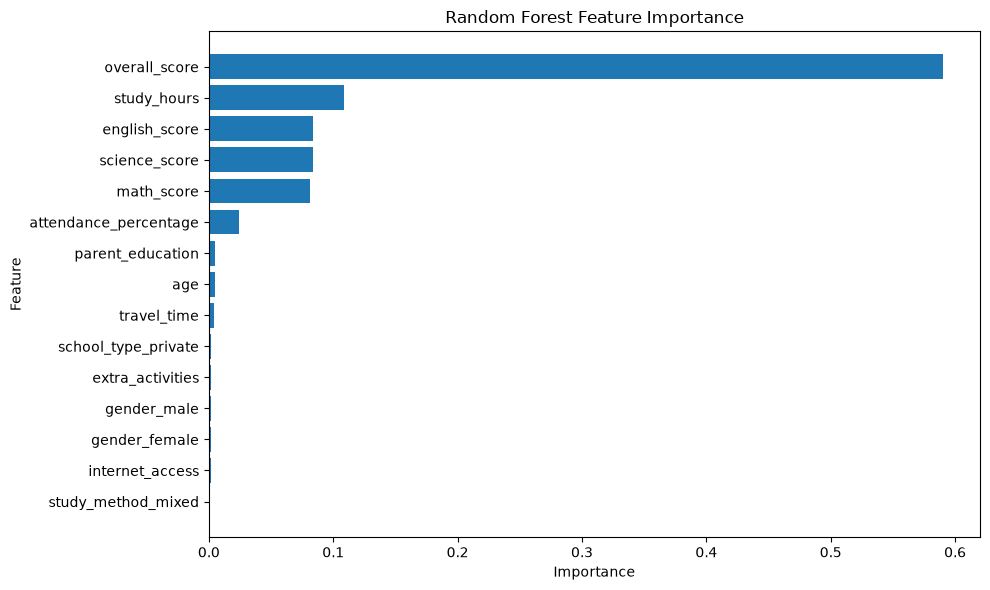

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [57]:
# Check how overall_score relates to final_grade

print("Overall score statistics by final grade:")
print(
    ml_df.groupby("final_grade")["overall_score"]
    .agg(["count", "min", "max", "mean", "median"])
)

Overall score statistics by final grade:
             count   min    max       mean  median
final_grade                                       
a              721  95.0  100.0  98.404577   99.10
b             1638  85.0   95.0  89.384799   89.20
c             3697  70.0   85.0  77.313822   77.10
d             3770  55.0   70.0  62.499469   62.35
e             3378  40.0   55.0  47.755625   47.80
f             1796  14.5   40.0  33.463140   34.60


In [58]:
# Check the distribution of overall scores for each grade

grade_score_ranges = (
    ml_df.groupby("final_grade")["overall_score"]
    .agg(["min", "max", "mean", "std"])
    .sort_index()
)

grade_score_ranges

,min,max,mean,std
final_grade,,,,
a,95.0,100.0,98.404577,1.756818
b,85.0,95.0,89.384799,2.835211
c,70.0,85.0,77.313822,4.318320
d,55.0,70.0,62.499469,4.364531
e,40.0,55.0,47.755625,4.283754
f,14.5,40.0,33.463140,5.008633


In [59]:
# Show a sample of the relevant columns

print(
    ml_df[
        ["math_score", "science_score", "english_score",
         "overall_score", "final_grade"]
    ].head(20).to_string(index=False)
)

 math_score  science_score  english_score  overall_score final_grade
       42.7           55.4           57.0           53.1           e
       57.6           68.8           64.8           61.3           d
       84.8           95.0           79.2           89.6           b
       44.4           27.5           54.7           41.6           e
        8.9           32.7           30.0           25.4           f
       51.5           78.3           63.9           63.5           d
       41.9           29.4           39.2           39.1           f
       56.7           60.1           53.4           69.6           d
       54.1           59.5           38.3           55.2           d
       71.9           70.4           81.3           69.6           d
       75.4           82.7           70.8           77.5           c
       62.0           54.7           58.0           65.0           d
       75.1           80.5           56.2           73.6           c
       33.6           26.8        

In [60]:
# Correlation between overall_score and encoded final grade

print(
    "Correlation between overall_score and final_grade_encoded:",
    ml_df["overall_score"].corr(ml_df["final_grade_encoded"])
)

Correlation between overall_score and final_grade_encoded: 0.9725241000005285


In [61]:
# Count how many different final grades occur for each overall score

score_grade_check = (
    ml_df.groupby("overall_score")["final_grade"]
    .nunique()
    .sort_values(ascending=False)
)

print(score_grade_check.head(20))

overall_score
55.0     2
40.0     2
70.0     2
85.0     2
95.0     2
100.0    1
14.5     1
16.7     1
17.1     1
17.7     1
96.9     1
19.5     1
19.6     1
19.7     1
19.8     1
20.0     1
20.1     1
20.2     1
20.3     1
20.4     1
Name: final_grade, dtype: int64


In [62]:
# Check correlation between overall score and encoded final grade

correlation = ml_df["overall_score"].corr(
    ml_df["final_grade_encoded"]
)

print("Correlation between overall_score and final_grade_encoded:")
print(correlation)

Correlation between overall_score and final_grade_encoded:
0.9725241000005285


In [63]:
# Examine overall score statistics for each final grade

grade_score_summary = (
    ml_df.groupby("final_grade")["overall_score"]
    .agg(["count", "min", "max", "mean", "median", "std"])
)

print(grade_score_summary)

             count   min    max       mean  median       std
final_grade                                                 
a              721  95.0  100.0  98.404577   99.10  1.756818
b             1638  85.0   95.0  89.384799   89.20  2.835211
c             3697  70.0   85.0  77.313822   77.10  4.318320
d             3770  55.0   70.0  62.499469   62.35  4.364531
e             3378  40.0   55.0  47.755625   47.80  4.283754
f             1796  14.5   40.0  33.463140   34.60  5.008633


In [64]:
# Compare subject scores and overall score across final grades

score_columns = [
    "math_score",
    "science_score",
    "english_score",
    "overall_score"
]

print(
    ml_df.groupby("final_grade")[score_columns]
    .mean()
)

             math_score  science_score  english_score  overall_score
final_grade                                                         
a             95.126491      95.193481      95.228849      98.404577
b             88.638217      89.103358      88.049634      89.384799
c             77.222369      77.192102      77.290289      77.313822
d             62.547321      62.323607      62.311273      62.499469
e             47.782771      47.719538      47.909207      47.755625
f             33.484410      33.489310      33.552394      33.463140


In [65]:
# Check whether overall_score is approximately the average
# of the three subject scores

calculated_average = (
    ml_df["math_score"]
    + ml_df["science_score"]
    + ml_df["english_score"]
) / 3

difference = (
    ml_df["overall_score"] - calculated_average
).abs()

print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())
print("Rows with difference <= 0.01:", (difference <= 0.01).sum())
print("Total rows:", len(ml_df))

Maximum difference: 22.10000000000001
Mean difference: 4.545364444444445
Rows with difference <= 0.01: 69
Total rows: 15000


In [66]:
# Check relationship between overall score and final grade

correlation = ml_df["overall_score"].corr(
    ml_df["final_grade_encoded"]
)

print("Correlation:", correlation)

Correlation: 0.9725241000005285


In [67]:
# Overall score distribution within each final grade

grade_score_summary = (
    ml_df.groupby("final_grade")["overall_score"]
    .agg(
        count="count",
        minimum="min",
        maximum="max",
        mean="mean",
        median="median",
        std="std"
    )
)

grade_score_summary

,count,minimum,maximum,mean,median,std
final_grade,,,,,,
a,721,95.0,100.0,98.404577,99.10,1.756818
b,1638,85.0,95.0,89.384799,89.20,2.835211
c,3697,70.0,85.0,77.313822,77.10,4.318320
d,3770,55.0,70.0,62.499469,62.35,4.364531
e,3378,40.0,55.0,47.755625,47.80,4.283754
f,1796,14.5,40.0,33.463140,34.60,5.008633


In [68]:
# Cross-tabulate final grade against overall-score ranges

ml_df["overall_score_band"] = pd.cut(
    ml_df["overall_score"],
    bins=[0, 40, 50, 60, 70, 80, 90, 100],
    include_lowest=True
)

grade_band_table = pd.crosstab(
    ml_df["overall_score_band"],
    ml_df["final_grade"]
)

grade_band_table

final_grade,a,b,c,d,e,f
overall_score_band,,,,,,
"(-0.001, 40.0]",0,0,0,0,11,1796
"(40.0, 50.0]",0,0,0,0,2184,0
"(50.0, 60.0]",0,0,0,1289,1183,0
"(60.0, 70.0]",0,0,14,2481,0,0
"(70.0, 80.0]",0,0,2505,0,0,0
"(80.0, 90.0]",0,972,1178,0,0,0
"(90.0, 100.0]",721,666,0,0,0,0


In [69]:
print("Final grade labels:")
print(sorted(ml_df["final_grade"].unique()))

Final grade labels:
['a', 'b', 'c', 'd', 'e', 'f']


In [70]:
print("\nGrade counts:")
print(ml_df["final_grade"].value_counts().sort_index())


Grade counts:
final_grade
a     721
b    1638
c    3697
d    3770
e    3378
f    1796
Name: count, dtype: int64


In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_score = ml_df[["overall_score"]]
y_grade = ml_df["final_grade_encoded"]

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score,
    y_grade,
    test_size=0.20,
    random_state=42,
    stratify=y_grade
)

score_only_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

score_only_model.fit(X_train_score, y_train_score)

score_only_pred = score_only_model.predict(X_test_score)

print(
    "Accuracy using ONLY overall_score:",
    accuracy_score(y_test_score, score_only_pred)
)

Accuracy using ONLY overall_score: 0.9973333333333333


In [72]:
# Create leakage-safe features by removing overall_score

X_no_overall = X.drop(columns=["overall_score"])

print("Original number of features:", X.shape[1])
print("Features after removing overall_score:", X_no_overall.shape[1])

print("\nRemaining features:")
print(X_no_overall.columns.tolist())

Original number of features: 19
Features after removing overall_score: 18

Remaining features:
['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'internet_access', 'extra_activities', 'travel_time', 'parent_education', 'gender_female', 'gender_male', 'school_type_private', 'study_method_coaching', 'study_method_group_study', 'study_method_mixed', 'study_method_notes', 'study_method_online_videos']


In [73]:
from sklearn.model_selection import train_test_split

X_train_no_overall, X_test_no_overall, y_train_no_overall, y_test_no_overall = train_test_split(
    X_no_overall,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train_no_overall.shape[0])
print("Testing rows:", X_test_no_overall.shape[0])

Training rows: 12000
Testing rows: 3000


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_no_overall = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_no_overall.fit(
    X_train_no_overall,
    y_train_no_overall
)

logistic_no_overall_pred = logistic_no_overall.predict(
    X_test_no_overall
)

print("Logistic Regression — without overall_score")
print("Accuracy :", accuracy_score(y_test_no_overall, logistic_no_overall_pred))
print("Precision:", precision_score(
    y_test_no_overall,
    logistic_no_overall_pred,
    average="macro"
))
print("Recall   :", recall_score(
    y_test_no_overall,
    logistic_no_overall_pred,
    average="macro"
))
print("F1       :", f1_score(
    y_test_no_overall,
    logistic_no_overall_pred,
    average="macro"
))

Logistic Regression — without overall_score
Accuracy : 0.6716666666666666
Precision: 0.64518227262385
Recall   : 0.6068249891696683
F1       : 0.620050921507507


c:\Users\Owner\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
from sklearn.ensemble import RandomForestClassifier

random_forest_no_overall = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_no_overall.fit(
    X_train_no_overall,
    y_train_no_overall
)

random_forest_no_overall_pred = random_forest_no_overall.predict(
    X_test_no_overall
)

print("Random Forest — without overall_score")
print("Accuracy :", accuracy_score(
    y_test_no_overall,
    random_forest_no_overall_pred
))
print("Precision:", precision_score(
    y_test_no_overall,
    random_forest_no_overall_pred,
    average="macro"
))
print("Recall   :", recall_score(
    y_test_no_overall,
    random_forest_no_overall_pred,
    average="macro"
))
print("F1       :", f1_score(
    y_test_no_overall,
    random_forest_no_overall_pred,
    average="macro"
))

Random Forest — without overall_score
Accuracy : 0.7623333333333333
Precision: 0.7682544935774919
Recall   : 0.7390997692038918
F1       : 0.7517662534912573


In [76]:
comparison_no_overall = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test_no_overall, logistic_no_overall_pred),
        accuracy_score(y_test_no_overall, random_forest_no_overall_pred)
    ],
    "Macro Precision": [
        precision_score(y_test_no_overall, logistic_no_overall_pred, average="macro"),
        precision_score(y_test_no_overall, random_forest_no_overall_pred, average="macro")
    ],
    "Macro Recall": [
        recall_score(y_test_no_overall, logistic_no_overall_pred, average="macro"),
        recall_score(y_test_no_overall, random_forest_no_overall_pred, average="macro")
    ],
    "Macro F1": [
        f1_score(y_test_no_overall, logistic_no_overall_pred, average="macro"),
        f1_score(y_test_no_overall, random_forest_no_overall_pred, average="macro")
    ]
})

comparison_no_overall

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.671667,0.645182,0.606825,0.620051
1,Random Forest,0.762333,0.768254,0.739100,0.751766


In [77]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression
logistic_cv = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_scores = cross_validate(
    logistic_cv,
    X_no_overall,
    y,
    cv=cv,
    scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    n_jobs=-1
)

# Random Forest
random_forest_cv = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_scores = cross_validate(
    random_forest_cv,
    X_no_overall,
    y,
    cv=cv,
    scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    n_jobs=-1
)

print("LOGISTIC REGRESSION — 5-FOLD CV")
print("Accuracy :", logistic_scores["test_accuracy"].mean())
print("Precision:", logistic_scores["test_precision_macro"].mean())
print("Recall   :", logistic_scores["test_recall_macro"].mean())
print("F1       :", logistic_scores["test_f1_macro"].mean())

print("\nRANDOM FOREST — 5-FOLD CV")
print("Accuracy :", random_forest_scores["test_accuracy"].mean())
print("Precision:", random_forest_scores["test_precision_macro"].mean())
print("Recall   :", random_forest_scores["test_recall_macro"].mean())
print("F1       :", random_forest_scores["test_f1_macro"].mean())

LOGISTIC REGRESSION — 5-FOLD CV
Accuracy : 0.6815333333333333
Precision: 0.6472919621461185
Recall   : 0.6187872413081041
F1       : 0.6278328086598906

RANDOM FOREST — 5-FOLD CV
Accuracy : 0.7564
Precision: 0.7537204841835109
Recall   : 0.7265435821623125
F1       : 0.7383170503471367


In [78]:
print("Random Forest fold accuracies:")
print(random_forest_scores["test_accuracy"])

print("\nRandom Forest accuracy standard deviation:")
print(random_forest_scores["test_accuracy"].std())

print("\nRandom Forest fold Macro F1:")
print(random_forest_scores["test_f1_macro"])

print("\nRandom Forest Macro F1 standard deviation:")
print(random_forest_scores["test_f1_macro"].std())

Random Forest fold accuracies:
[0.75333333 0.75433333 0.761      0.755      0.75833333]

Random Forest accuracy standard deviation:
0.0028472208672083604

Random Forest fold Macro F1:
[0.73995596 0.73301207 0.73790243 0.73519194 0.74552284]

Random Forest Macro F1 standard deviation:
0.0043055895979184486


In [79]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Random Forest
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_no_overall, y)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

Best cross-validation Macro F1:
0.7444610176173292


In [80]:
print("BEST PARAMETERS")
for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")

print("\nBEST CROSS-VALIDATION MACRO F1:")
print(grid_search.best_score_)

BEST PARAMETERS
max_depth: 15
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 10
n_estimators: 200

BEST CROSS-VALIDATION MACRO F1:
0.7444610176173292


In [81]:
# Get the best tuned Random Forest
final_rf = grid_search.best_estimator_

# Predict on the untouched test set
final_rf_pred = final_rf.predict(X_test_no_overall)

print("Final tuned Random Forest trained successfully.")
print("Test predictions:", len(final_rf_pred))

Final tuned Random Forest trained successfully.
Test predictions: 3000


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(
    y_test_no_overall,
    final_rf_pred
)

final_precision = precision_score(
    y_test_no_overall,
    final_rf_pred,
    average="macro"
)

final_recall = recall_score(
    y_test_no_overall,
    final_rf_pred,
    average="macro"
)

final_f1 = f1_score(
    y_test_no_overall,
    final_rf_pred,
    average="macro"
)

print("FINAL TUNED RANDOM FOREST RESULTS")
print("---------------------------------")
print(f"Accuracy:        {final_accuracy:.4f}")
print(f"Macro Precision: {final_precision:.4f}")
print(f"Macro Recall:    {final_recall:.4f}")
print(f"Macro F1:        {final_f1:.4f}")

FINAL TUNED RANDOM FOREST RESULTS
---------------------------------
Accuracy:        0.9117
Macro Precision: 0.9225
Macro Recall:    0.9043
Macro F1:        0.9127


In [83]:
from sklearn.metrics import classification_report

print("FINAL TUNED RANDOM FOREST - CLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test_no_overall,
        final_rf_pred,
        digits=4
    )
)

FINAL TUNED RANDOM FOREST - CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9503    0.9053    0.9272       359
           1     0.9052    0.9038    0.9045       676
           2     0.8957    0.9111    0.9034       754
           3     0.9128    0.9350    0.9238       739
           4     0.8943    0.9024    0.8983       328
           5     0.9766    0.8681    0.9191       144

    accuracy                         0.9117      3000
   macro avg     0.9225    0.9043    0.9127      3000
weighted avg     0.9123    0.9117    0.9117      3000



Confusion Matrix:
[[325  34   0   0   0   0]
 [ 17 611  48   0   0   0]
 [  0  30 687  37   0   0]
 [  0   0  32 691  16   0]
 [  0   0   0  29 296   3]
 [  0   0   0   0  19 125]]


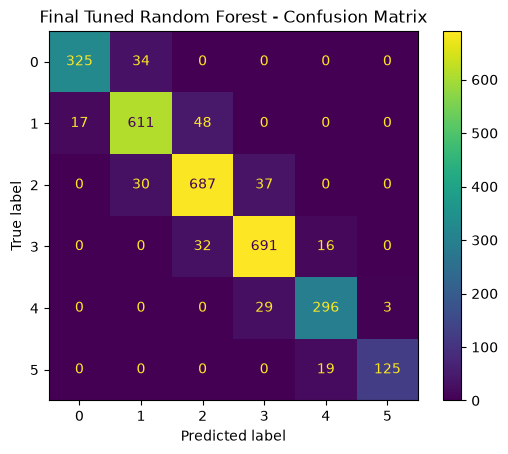

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_no_overall,
    final_rf_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Final Tuned Random Forest - Confusion Matrix")
plt.show()

In [85]:
from sklearn.metrics import classification_report

print("FINAL TUNED RANDOM FOREST - CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_test_no_overall,
    final_rf_pred,
    digits=4
)

print(report)

FINAL TUNED RANDOM FOREST - CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9503    0.9053    0.9272       359
           1     0.9052    0.9038    0.9045       676
           2     0.8957    0.9111    0.9034       754
           3     0.9128    0.9350    0.9238       739
           4     0.8943    0.9024    0.8983       328
           5     0.9766    0.8681    0.9191       144

    accuracy                         0.9117      3000
   macro avg     0.9225    0.9043    0.9127      3000
weighted avg     0.9123    0.9117    0.9117      3000



FINAL TUNED RANDOM FOREST - FEATURE IMPORTANCE
                   Feature  Importance
               study_hours    0.258194
             science_score    0.191599
             english_score    0.189281
                math_score    0.185514
     attendance_percentage    0.082953
                       age    0.016838
          parent_education    0.016791
               travel_time    0.012542
          extra_activities    0.005724
       school_type_private    0.005404
             gender_female    0.005096
               gender_male    0.005061
     study_method_coaching    0.004370
  study_method_group_study    0.004314
        study_method_mixed    0.004310
study_method_online_videos    0.004081
           internet_access    0.003981
        study_method_notes    0.003947


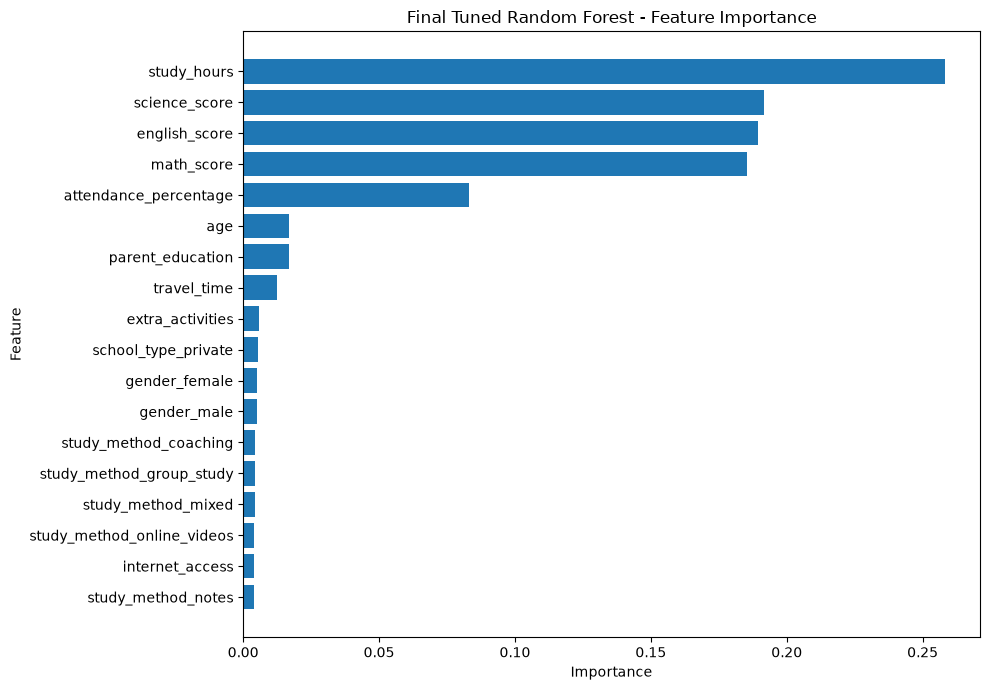

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the final tuned Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_no_overall.columns,
    "Importance": final_rf.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("FINAL TUNED RANDOM FOREST - FEATURE IMPORTANCE")
print("=" * 60)
print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Final Tuned Random Forest - Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

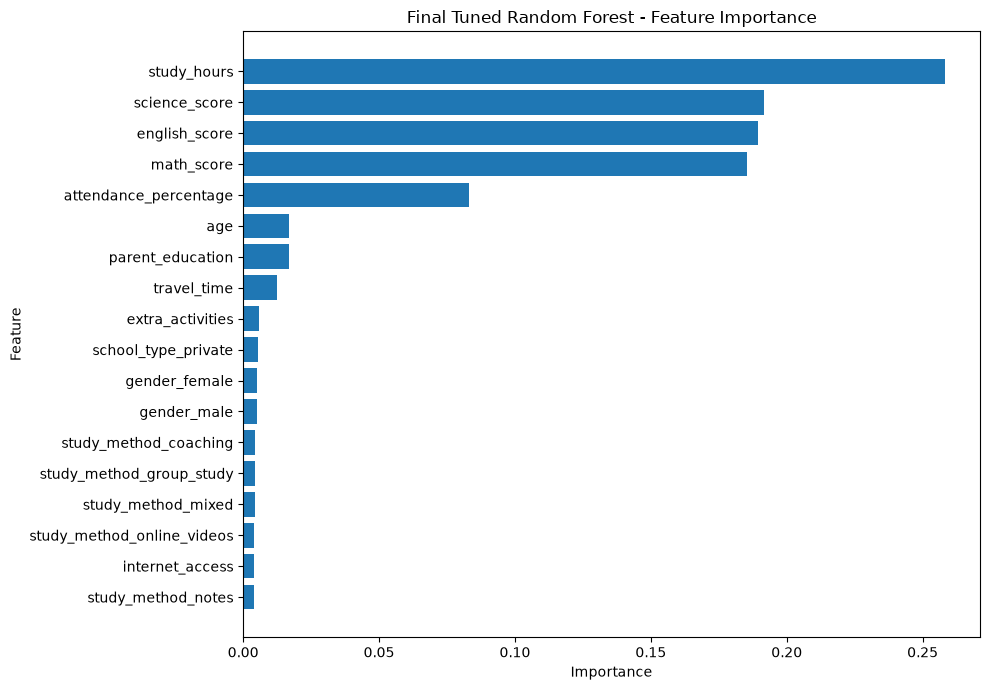

Saved:
ML_Results/final_feature_importance.csv
ML_Results/final_random_forest_feature_importance.png


In [87]:
import os

# Make sure ML_Results folder exists
os.makedirs("ML_Results", exist_ok=True)

# Save feature importance table
feature_importance.to_csv(
    "ML_Results/final_feature_importance.csv",
    index=False
)

# Save feature importance figure
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Final Tuned Random Forest - Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "ML_Results/final_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("ML_Results/final_feature_importance.csv")
print("ML_Results/final_random_forest_feature_importance.png")

In [88]:
import joblib

# Save the final tuned Random Forest model
joblib.dump(
    final_rf,
    "ML_Results/final_tuned_random_forest.joblib"
)

print("Final tuned Random Forest saved successfully.")
print("ML_Results/final_tuned_random_forest.joblib")

Final tuned Random Forest saved successfully.
ML_Results/final_tuned_random_forest.joblib


In [89]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_results.to_csv(
    "ML_Results/final_model_metrics.csv",
    index=False
)

print("FINAL MODEL METRICS")
print("=" * 40)
print(final_results.to_string(index=False))

print("\nSaved:")
print("ML_Results/final_model_metrics.csv")

FINAL MODEL METRICS
         Metric    Score
       Accuracy 0.911667
Macro Precision 0.922469
   Macro Recall 0.904304
       Macro F1 0.912727

Saved:
ML_Results/final_model_metrics.csv


In [90]:
import joblib
import os

model_path = "ML_Results/final_tuned_random_forest.joblib"

# Check that the file exists
print("Model file exists:", os.path.exists(model_path))

# Load the saved model
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")
print("Model type:", type(loaded_model).__name__)

Model file exists: True
Model loaded successfully!
Model type: RandomForestClassifier


In [91]:
# Use the loaded model to predict the test set
loaded_predictions = loaded_model.predict(X_test_no_overall)

print("Predictions generated:", len(loaded_predictions))
print("Actual test samples:", len(y_test_no_overall))

# Check whether predictions match the original final model
same_predictions = (loaded_predictions == final_rf_pred).all()

print("Predictions match original model:", same_predictions)

Predictions generated: 3000
Actual test samples: 3000
Predictions match original model: True


In [92]:
from sklearn.metrics import accuracy_score, f1_score

loaded_accuracy = accuracy_score(
    y_test_no_overall,
    loaded_predictions
)

loaded_f1 = f1_score(
    y_test_no_overall,
    loaded_predictions,
    average="macro"
)

print("Loaded model accuracy:", round(loaded_accuracy, 6))
print("Loaded model Macro F1:", round(loaded_f1, 6))

Loaded model accuracy: 0.911667
Loaded model Macro F1: 0.912727


In [93]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Final Tuned Random Forest"
    ],
    "Accuracy": [
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Logistic Regression",
            "Accuracy"
        ].iloc[0],
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Random Forest",
            "Accuracy"
        ].iloc[0],
        final_accuracy
    ],
    "Macro Precision": [
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Logistic Regression",
            "Macro Precision"
        ].iloc[0],
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Random Forest",
            "Macro Precision"
        ].iloc[0],
        final_precision
    ],
    "Macro Recall": [
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Logistic Regression",
            "Macro Recall"
        ].iloc[0],
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Random Forest",
            "Macro Recall"
        ].iloc[0],
        final_recall
    ],
    "Macro F1": [
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Logistic Regression",
            "Macro F1"
        ].iloc[0],
        comparison_no_overall.loc[
            comparison_no_overall["Model"] == "Random Forest",
            "Macro F1"
        ].iloc[0],
        final_f1
    ]
})

final_comparison = final_comparison.round(4)

final_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.6717,0.6452,0.6068,0.6201
1,Random Forest,0.7623,0.7683,0.7391,0.7518
2,Final Tuned Random Forest,0.9117,0.9225,0.9043,0.9127


In [94]:
final_comparison.to_csv(
    "ML_Results/final_model_comparison.csv",
    index=False
)

print("Final comparison saved successfully.")
print("ML_Results/final_model_comparison.csv")

Final comparison saved successfully.
ML_Results/final_model_comparison.csv


In [95]:
summary_text = f"""
FINAL STUDENT PERFORMANCE MODEL SUMMARY
=======================================

Final Model:
Tuned Random Forest

Target:
Student performance category

Important leakage decision:
overall_score was excluded from the final feature set.

Final Test Results:
Accuracy          : {final_accuracy:.4f}
Macro Precision   : {final_precision:.4f}
Macro Recall      : {final_recall:.4f}
Macro F1          : {final_f1:.4f}

Test Samples:
{len(y_test_no_overall)}

Final Model Parameters:
{grid_search.best_params_}

Best Cross-Validation Macro F1:
{grid_search.best_score_:.4f}

Model Verification:
The saved Random Forest model was loaded from disk and
successfully reproduced the original test predictions.

Loaded Model Accuracy:
{loaded_accuracy:.4f}

Loaded Model Macro F1:
{loaded_f1:.4f}

Major Features by Random Forest Importance:
study_hours
science_score
english_score
math_score
attendance_percentage
"""

with open(
    "ML_Results/final_project_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

print("Final project summary saved successfully.")

Final project summary saved successfully.


# Student Performance Analysis and Machine Learning

## Project Overview

This project analyzes student performance data and develops machine learning models to predict student performance categories.

The workflow includes:

- Data inspection and cleaning
- Exploratory data analysis
- Feature engineering
- Target leakage investigation
- Baseline model training
- Cross-validation
- Hyperparameter tuning
- Final model evaluation
- Feature importance analysis
- Model persistence and verification

## Target Leakage Investigation

The feature `overall_score` was investigated because it is closely related to the target and can cause target leakage.

For the final machine learning evaluation, `overall_score` was excluded from the feature set.

This provides a more realistic assessment of model performance.

## Models

The project evaluated:

- Logistic Regression
- Random Forest
- Tuned Random Forest

The final model is a tuned Random Forest classifier.

## Final Model

### Tuned Random Forest

Test-set performance:

| Metric | Score |
|---|---:|
| Accuracy | 0.9117 |
| Macro Precision | 0.9225 |
| Macro Recall | 0.9043 |
| Macro F1 | 0.9127 |

The test set contains 3,000 samples.

## Cross-Validation

The tuned Random Forest achieved a cross-validation Macro F1 score of approximately 0.7445 during hyperparameter tuning.

The final test-set evaluation is reported separately to avoid confusing cross-validation performance with held-out test performance.

## Feature Importance

The most important features identified by the Random Forest include:

1. Study hours
2. Science score
3. English score
4. Math score
5. Attendance percentage

## Model Verification

The final Random Forest model was saved as a `.joblib` file.

The saved model was subsequently loaded from disk and tested again.

The reloaded model produced:

- Accuracy: 0.911667
- Macro F1: 0.912727

This confirms that the saved model can be successfully loaded and used for prediction.

## Project Outputs

Important outputs are stored in `ML_Results/`, including:

- Final model metrics
- Model comparison
- Cross-validation results
- Hyperparameter tuning results
- Feature importance
- Final project summary
- Saved machine-learning model

## Conclusion

The project demonstrates a complete machine-learning workflow for student performance classification, including explicit investigation of target leakage, model validation, hyperparameter tuning, final evaluation, feature importance analysis, and saved-model verification.